In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
from jaxopt import Bisection, Broyden, ScipyBoundedMinimize
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

import os
os.environ["R_HOME"] = "/opt/homebrew/Cellar/r/4.5.2_1/lib/R"
import rpy2.robjects as robjects
from rpy2.robjects import FloatVector
import pyreadr

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MMD

In [2]:
#===========================================
# Load R Script
#===========================================

robjects.r['source']('script.R')
logposterior_R = robjects.globalenv['logposterior']
logposterior = lambda p: jnp.array(logposterior_R(FloatVector(p)))[0]


  
 - See www.r-inla.org/contact-us for how to get help.
 - List available models/likelihoods/etc with inla.list.models()
 - Use inla.doc(<NAME>) to access documentation
  
- See https://davidbolin.github.io/rSPDE for vignettes and manuals.
  
  


In [3]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
n_init = 20
bounds = ( jnp.array([0.1, 0.1, 0.1]), jnp.array([5.0, 5.0, 5.0]) )
halton = HaltonSequence(dim=3, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=n_init, n_eval=80000, sequence=halton)
polyfm = PolynomialFeatures(degree=2, include_bias=False)

X = halton.generate(jnp.arange(n_init))
y = jnp.array([ logposterior(x) for x in X ])
w = jnp.exp( y - jsp.special.logsumexp( y ) )

for ith in tqdm(range(n_init, 200)):
    #====== fit GP ======
    pr = LinearRegression()
    pr.fit(polyfm.fit_transform(X), y)
    gp_mean = lambda x: 0.0
    gp_kernel = gpx.kernels.RBF(n_dims=3, lengthscale=jnp.array([1.0, 1.0, 1.0]), variance=jnp.array([20.0]))
    gp = GP(gp_mean, gp_kernel)
    key, _key = jax.random.split(key)
    gp.tune_kernel_parameter(X, y - pr.predict(polyfm.fit_transform(X)), rng_key=_key)
    gp.fit(X, y - pr.predict(polyfm.fit_transform(X)))
    posterior_mean = jax.vmap(gp.posterior_mean, in_axes=0, out_axes=0)
    posterior_scale = jax.vmap(gp.posterior_scale, in_axes=0, out_axes=0)
    objective_gp = jax.vmap(gp.log_jensen_exp, in_axes=0, out_axes=0)
    objective = lambda Z: pr.predict(polyfm.fit_transform(Z)) + objective_gp(Z)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = logposterior(X_new)
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    w = jnp.exp( y - jsp.special.logsumexp( y ) )
    #====================


  0%|                                                                                              | 0/180 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|▍                                                                                     | 1/180 [00:01<05:48,  1.95s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|▉                                                                                     | 2/180 [00:03<04:43,  1.59s/it]

...

 99%|███████████████████████████████████████████████████████████████████████████████████ | 178/180 [07:05<00:08,  4.47s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

 99%|███████████████████████████████████████████████████████████████████████████████████▌| 179/180 [07:09<00:04,  4.49s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 180/180 [07:14<00:00,  2.41s/it]


(0.0, 4.5)

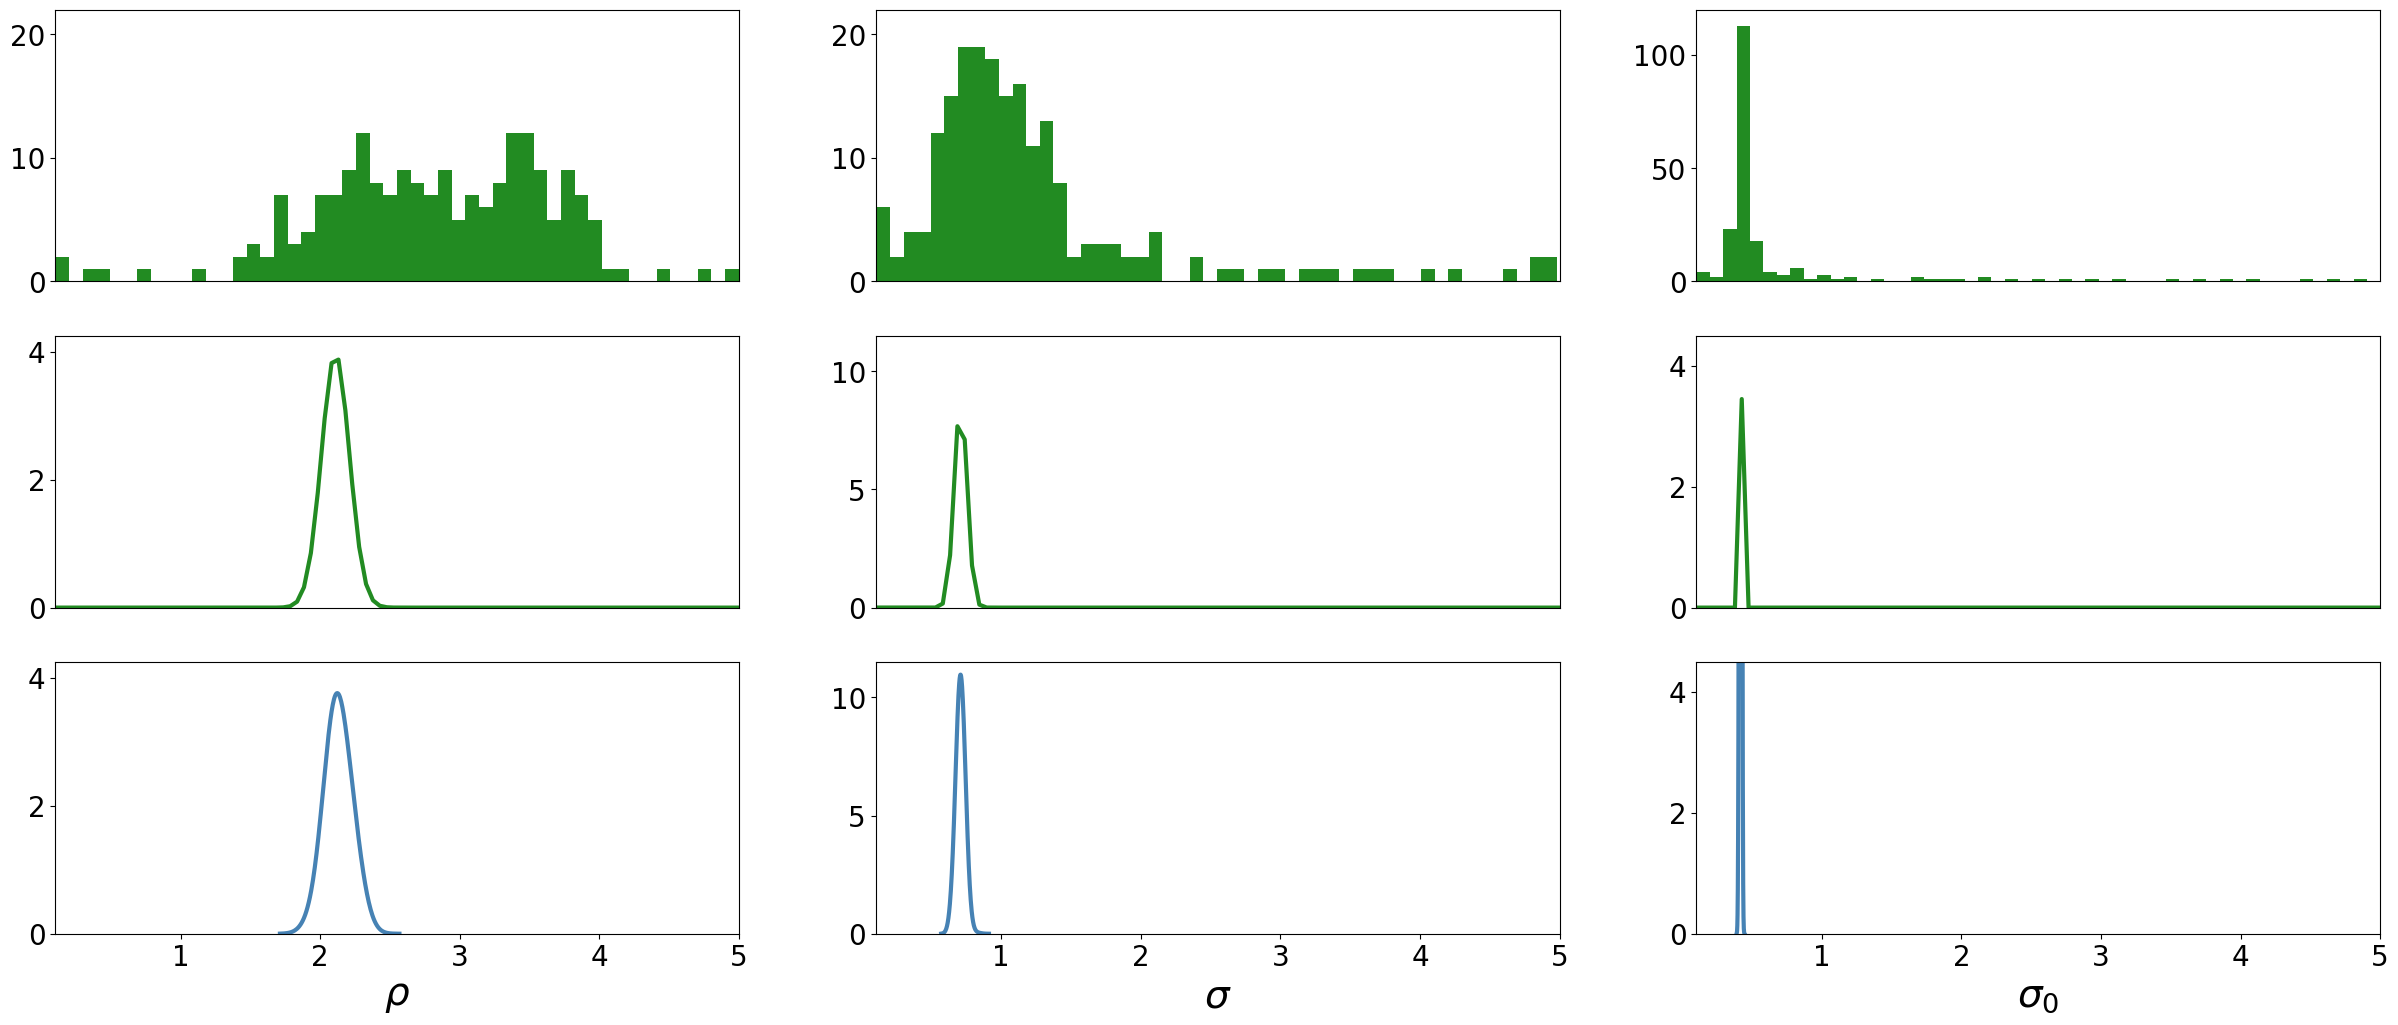

In [4]:
#===========================================
# Plot
#===========================================
from matplotlib.ticker import FormatStrFormatter

samples = jnp.array(pyreadr.read_r('Data/samples.rds')[None].to_numpy())

fig, axs = plt.subplots(3, 3, figsize=(30, 12))

for i in range(3):
    axs[0,i].hist(X[:,i], bins=50, color="forestgreen", zorder=2)
    axs[0,i].set_xlim(0.1, 5)
    axs[0,i].set_ylabel("")
    axs[0,i].set_xlabel("")
    axs[0,i].tick_params(axis='both', which='major', labelsize=20)
    axs[0,i].set_xticks([])

axs[0,0].set_ylim(0.0, 22)
axs[0,1].set_ylim(0.0, 22)
axs[0,2].set_ylim(0.0, 120)

for i in range(3):
    sns.kdeplot(x=X[:,i], weights=w, bw_method=1.0, linewidth=3, zorder=2, color="forestgreen", ax=axs[1,i])
    axs[1,i].set_xlim(0.1, 5)
    axs[1,i].set_ylabel("")
    axs[1,i].set_xlabel("")
    axs[1,i].tick_params(axis='both', which='major', labelsize=20)
    axs[1,i].set_xticks([])

axs[1,0].set_ylim(0.0, 4.25)
axs[1,1].set_ylim(0.0, 11.5)
axs[1,2].set_ylim(0.0, 4.5)

for i in range(3):
    sns.kdeplot(x=samples[:,i], bw_method=1.0, color="steelblue", linewidth=3, zorder=2, ax=axs[2,i])
    axs[2,i].set_xlim(0.1, 5)
    if i == 0:
        axs[2,i].set_xlabel(r"$\rho$", fontsize=28)
    elif i == 1:
        axs[2,i].set_xlabel(r"$\sigma$", fontsize=28)
    else:
        axs[2,i].set_xlabel(r"$\sigma_0$", fontsize=28)
    axs[2,i].set_ylabel("")
    axs[2,i].tick_params(axis='both', which='major', labelsize=20)

axs[2,0].set_ylim(0.0, 4.25)
axs[2,1].set_ylim(0.0, 11.5)
axs[2,2].set_ylim(0.0, 4.5)
